In [2]:
# Native libraries
import os
import math
import csv
# Essential Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
# Algorithms
#from minisom import MiniSom
from tslearn.barycenters import dtw_barycenter_averaging
from tslearn.clustering import TimeSeriesKMeans
from sklearn.cluster import KMeans
import cartopy.crs as ccrs
import cartopy
import susi
from sklearn.model_selection import GridSearchCV
import xarray as xr
from scipy.stats import kendalltau
from scipy import stats
from sklearn.decomposition import PCA

/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
/home/queenle/.conda/envs/myenv/lib/python3.6/site-packages/tslearn/clustering/kmeans.py:17: UserWarning: Scikit-learn <0.24 will be deprecated in a future release of tslearn
  "Scikit-learn <0.24 will be deprecated in a "


In [4]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)

metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/all_sites_all_seasons.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

# define alpha and numeric season order
seasons_a = ['fall','winter','spring','summer']
seasons_n = [3,6,9,12]

colors = ['r','b',"#000000", "#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941", "#006FA6", "#A30059",
"#FFDBE5", "#7A4900", "#0000A6", "#63FFAC", "#B79762", "#004D43", "#8FB0FF", "#997D87",
"#5A0007", "#809693", "#FEFFE6", "#1B4400", "#4FC601", "#3B5DFF", "#4A3B53", "#FF2F80",
"#61615A", "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9", "#B903AA", "#D16100",
"#DDEFFF", "#000035", "#7B4F4B", "#A1C299", "#300018", "#0AA6D8", "#013349", "#00846F",
"#372101", "#FFB500", "#C2FFED", "#A079BF", "#CC0744", "#C0B9B2", "#C2FF99", "#001E09",
"#00489C", "#6F0062", "#0CBD66", "#EEC3FF", "#456D75", "#B77B68", "#7A87A1", "#788D66",
"#885578", "#FAD09F", "#FF8A9A", "#D157A0", "#BEC459", "#456648", "#0086ED", "#886F4C",
"#34362D", "#B4A8BD", "#00A6AA", "#452C2C", "#636375", "#A3C8C9", "#FF913F", "#938A81",
"#575329", "#00FECF", "#B05B6F", "#8CD0FF", "#3B9700", "#04F757", "#C8A1A1", "#1E6E00",
"#7900D7", "#A77500", "#6367A9", "#A05837", "#6B002C", "#772600", "#D790FF", "#9B9700",
"#549E79", "#FFF69F", "#201625", "#72418F", "#BC23FF", "#99ADC0", "#3A2465", "#922329",
"#5B4534", "#FDE8DC", "#404E55", "#0089A3", "#CB7E98", "#A4E804", "#324E72", "#6A3A4C"]

colors.pop(34)
colors.pop(35)
colors.pop(20)
colors[15], colors[40] = colors[40], colors[15]

markers = ['s','.','*','^']

In [27]:
old_flow = pd.read_csv('/nesi/project/niwa02986/queenle/all_site_50yr')
old_flow.date = pd.to_datetime(old_flow.date)
old_flow.set_index('date', inplace=True)

current_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/all_sites_all_seasons.csv')
current_df.date = pd.to_datetime(current_df.date)
current_df.set_index('date', inplace=True)


In [40]:
for site in old_flow:
    if old_flow[site][100] != current_df[site][100]:
        print(site)

In [41]:
current_df['64610']

date
1969-12-01     51993.34444
1970-03-01    443995.04350
1970-06-01    710072.91300
1970-09-01    292755.50550
1970-12-01    124024.82220
                  ...     
2018-09-01    438685.93410
2018-12-01    302570.23330
2019-03-01    229510.34780
2019-06-01    758822.03260
2019-09-01    309040.84620
Name: 64610, Length: 200, dtype: float64

In [39]:
old_flow['46618'][0]

nan

In [8]:
norm_df = (flow_df - flow_df.mean())/flow_df.std()

In [9]:
winter = {1: [1316, 3506, 46618, 46651, 4901, 9301],
          2: [1043427, 1043428, 1043461, 1043466, 15408, 15410, 16501, 32503, 9205,
                       21412, 21801, 23104, 29224, 29808, 33117, 33316, 33347, 36001, 43472],
          3: [52916, 57009, 60114, 64602, 65104, 71116, 71120, 71123, 71129, 
              71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
          4: [60104, 62105, 64610, 68001, 68806, 69621, 73501, 62103], 
         }

winter_names = {1: 'Northland',2: 'Central North Island',3:'West South Island',4:'East South Island'}
                   
summer = {1: [1043427, 1043428, 1043461, 1316, 15410, 16501, 21412, 21801, 23104, 32503, 
              33316, 3506, 43472, 46618, 46651, 4901, 9205, 9301, 15408],
          2: [1043466, 29224, 29808, 33117, 33347, 36001],
          3: [60114, 64602, 65104, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 
              75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101,52916],
          4: [57009, 60104, 62103, 62105, 64610, 68001, 68806, 69621,73501]
          }

summer_names = {1:'Northland', 2:'South North Island', 3:'West South Island', 4:'East South Island'}

autumn = {1: [1043427, 1043428, 1043461, 1043466, 1316, 15408, 15410, 16501, 21412, 21801, 
              23104, 32503, 33316, 33347, 3506, 43472, 46618, 46651, 4901, 9205, 9301],
          2: [29224, 29808, 33117, 36001, 52916, 57009, 60104, 60114, 62103, 62105, 64602, 
              64610, 65104, 68001, 68806, 69621, 71116, 71120, 71123, 71129, 71132, 71135, 
              73501, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
         }

autumn_names = {1:'North', 2:'South'}

spring = {1: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 
              3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301],
          2: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 
              60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 
              71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
          }
spring_names = {1: 'East', 2: 'West'}


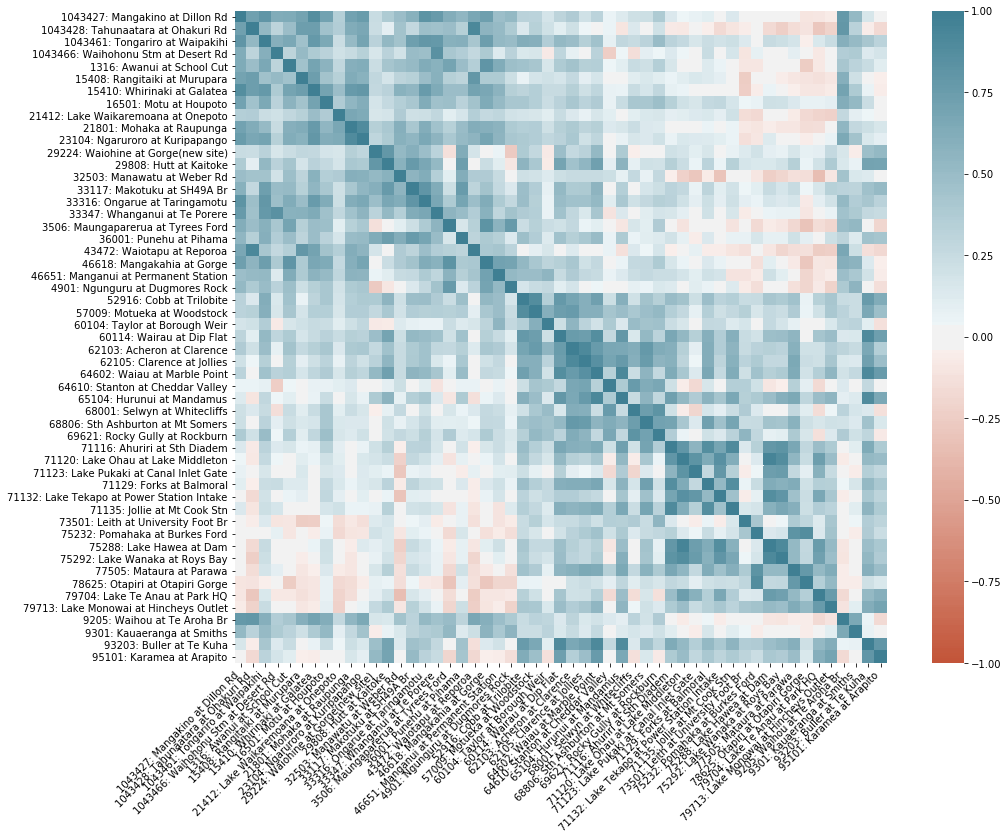

In [10]:
fig,ax = plt.subplots(figsize=(16,12))

#df = flow_df[flow_df.index.month.isin([12])]
df = norm_df[norm_df.index.month.isin([12])]

corr = df.corr()
ax = sns.heatmap(
    corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)

labels = [site + ': ' + metadata_df.loc[int(site)]['Name'] for site in df.columns]

#print(corr)

ax.set_xticklabels(
    labels,
    rotation=45,
    horizontalalignment='right'
)

ax.set_yticklabels(
    labels,
    #rotation=45,
    #horizontalalignment='right'
)

plt.show()

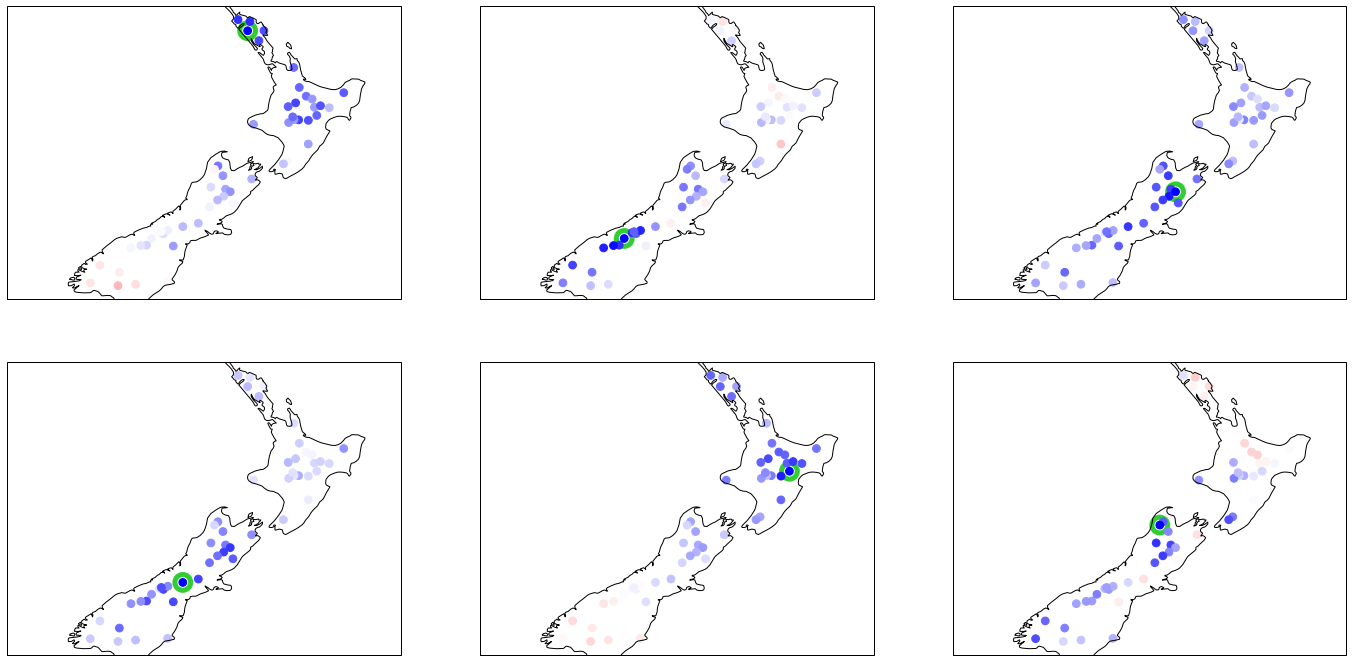

In [11]:
fig, ax = plt.subplots(2,3,figsize=(24,12),subplot_kw={'projection': ccrs.PlateCarree()})
axs = ax.flatten()

site_numbers = [46618,71120,62103,68806,21801,95101]

for i,s in enumerate(site_numbers):
    site_corr = corr[str(s)]

    #print(site_corr.loc['1316'])

    lons = []
    lats = []
    corrs = []


    for site in site_corr.index:


        lons.append(metadata_df.loc[int(site)]['centroid_lon'])
        lats.append(metadata_df.loc[int(site)]['centroid_lat'])
        corrs.append(site_corr.loc[site])

        if site == str(s):
            axs[i].scatter(metadata_df.loc[int(site)]['centroid_lon'],metadata_df.loc[int(site)]['centroid_lat'],marker='o',s=250,facecolors='none',edgecolors='limegreen',linewidth=5)

    im = axs[i].scatter(lons,lats,c=corrs,cmap='bwr_r',marker='o',s=60,vmin=-1,vmax=1)

    axs[i].coastlines(resolution='50m', color='black',linewidth=1)
    axs[i].set_xlim([164,180])

#fig.colorbar(im, ax=ax)
#plt.tight_layout()


In [14]:
df

,1043427,1043428,1043461,1043466,1316,15408,15410,16501,21412,21801,...,75288,75292,77505,78625,79704,79713,9205,9301,93203,95101
date,,,,,,,,,,,,,,,,,,,,,
1970-09-01,2.064099,1.644554,1.736306,1.154994,0.027452,2.929443,2.908549,2.000577,0.337191,1.053208,...,2.505418,2.723613,0.721538,0.658029,1.023687,0.713229,1.201243,0.444952,1.527615,0.801843
1971-09-01,2.367650,3.263668,1.411220,1.578602,1.150832,0.568422,2.192038,2.404119,1.581673,2.450965,...,0.409998,0.312795,-0.086626,0.035217,1.003980,1.141589,2.471478,0.420040,1.106678,0.308055
1972-09-01,-0.010335,0.362436,-0.758753,0.227125,-0.501979,0.568422,-0.382570,-0.906182,-0.773042,-1.050421,...,1.589027,1.316512,2.158853,0.876231,1.592341,1.329756,0.803616,-0.600515,1.622282,0.470420
1973-09-01,0.062194,1.021840,-0.077216,-0.575612,0.027452,-0.044987,0.402361,-0.472765,-0.860146,-0.079860,...,0.028954,0.589718,-0.422320,0.256158,-0.012786,-0.244618,0.677391,-0.429272,0.163210,-0.520224
1974-09-01,0.454182,0.362436,0.235827,0.081073,0.027452,1.363232,0.402361,-0.000756,0.408140,0.441423,...,-0.640961,-0.918286,0.126027,-0.636766,-1.776399,-1.378534,0.095121,-0.057103,-0.158120,-0.668919
1975-09-01,1.039900,1.110410,0.054024,0.892112,1.953098,1.487016,0.954975,0.264878,-0.210916,0.903662,...,0.638612,0.377371,0.594696,-0.532183,0.645397,-0.225039,0.863781,1.679307,0.427384,-0.397727
1976-09-01,0.350732,0.088598,-0.190488,0.526825,-0.244199,0.568422,0.452032,0.460141,2.153174,0.242430,...,-0.824289,-2.080229,-0.195608,-0.064130,-1.776203,-1.075659,1.604773,2.238961,-0.456102,-0.248152
1977-09-01,0.005891,0.106037,0.300018,-0.003954,-0.306894,0.412959,-0.547148,-0.428417,0.175133,0.920895,...,-0.658029,-1.183236,1.872353,1.075507,0.106253,0.652208,0.325759,-0.706726,-0.281898,0.276685
1978-09-01,-0.312350,-0.123316,0.293731,-0.725627,-0.316847,0.568422,0.402361,0.751189,-0.524242,0.128155,...,1.799199,1.247773,1.830828,0.622833,1.271032,0.684386,0.077884,-0.640979,0.109017,-0.398082


Text(0.5, 1.0, '1x1')

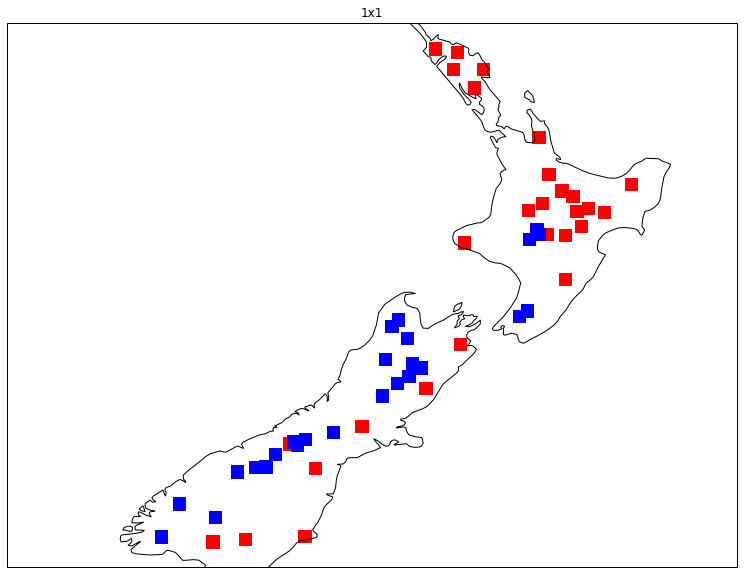

In [17]:
fig, ax = plt.subplots(figsize=(14,10),subplot_kw={'projection': ccrs.PlateCarree()})

#df = flow_df[flow_df.index.month.isin([9])]
df = norm_df[norm_df.index.month.isin([9])]

df = df.fillna(df.mean()).T
#normalized_df=((df-df.mean())/df.std()).T

#df = ((df - df['1979':'1999'].mean())/df['1979':'1999'].mean()).T

sites = df.index.values

#print(normalized_df)
X = df.values

som_x = 1
som_y = 2

som = susi.SOMClustering(som_x,som_y,n_iter_unsupervised=10000,learning_rate_start=0.5)
som.fit(X)
'''
umat = som.get_u_matrix()
p = plt.imshow(np.squeeze(umat))

fig.colorbar(p)
#print(umat)
'''
lons = []
lats = []
clusters = []

cluster_dict = {}

for x in range(som_x):
    for y in range(som_y):
        cluster = (x,y)
        cluster_number = x*som_y+y+1

        series_indices = som.get_datapoints_from_node(cluster)

        for j in series_indices:
            site = int(sites[j])

            lons.append(metadata_df.loc[site]['centroid_lon'])
            lats.append(metadata_df.loc[site]['centroid_lat'])
            clusters.append(cluster_number)
            
            if cluster_number not in cluster_dict:
                cluster_dict[cluster_number] = []
                
            cluster_dict[cluster_number].append(site)

ax.scatter(lons,lats,c=[colors[val-1] for val in clusters],marker='s',s=150)

ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.set_xlim([164,180])
ax.set_title(str(som_x) + "x" + str(som_x))



In [78]:
for key in cluster_dict:
    print(str(key) + ": [", end='')
    for val in cluster_dict[key]:
        print(str(val) + ", ",end='')
    print(']')

1: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101, ]
2: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301, ]


In [22]:
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/50plus.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

for site in [21412,79713,79704,75288,75292,71132,71123,71120,75292]:
    flow_df[str(site)] = flow_df[str(site)]*1000
    


In [85]:
subset = metadata_df.loc[[int(site) for site in flow_df.columns]]

subset[['Name','centroid_lat','centroid_lon','area_km2']].to_csv('streamflow_locations_50yearplus.csv')



No handles with labels found to put in legend.


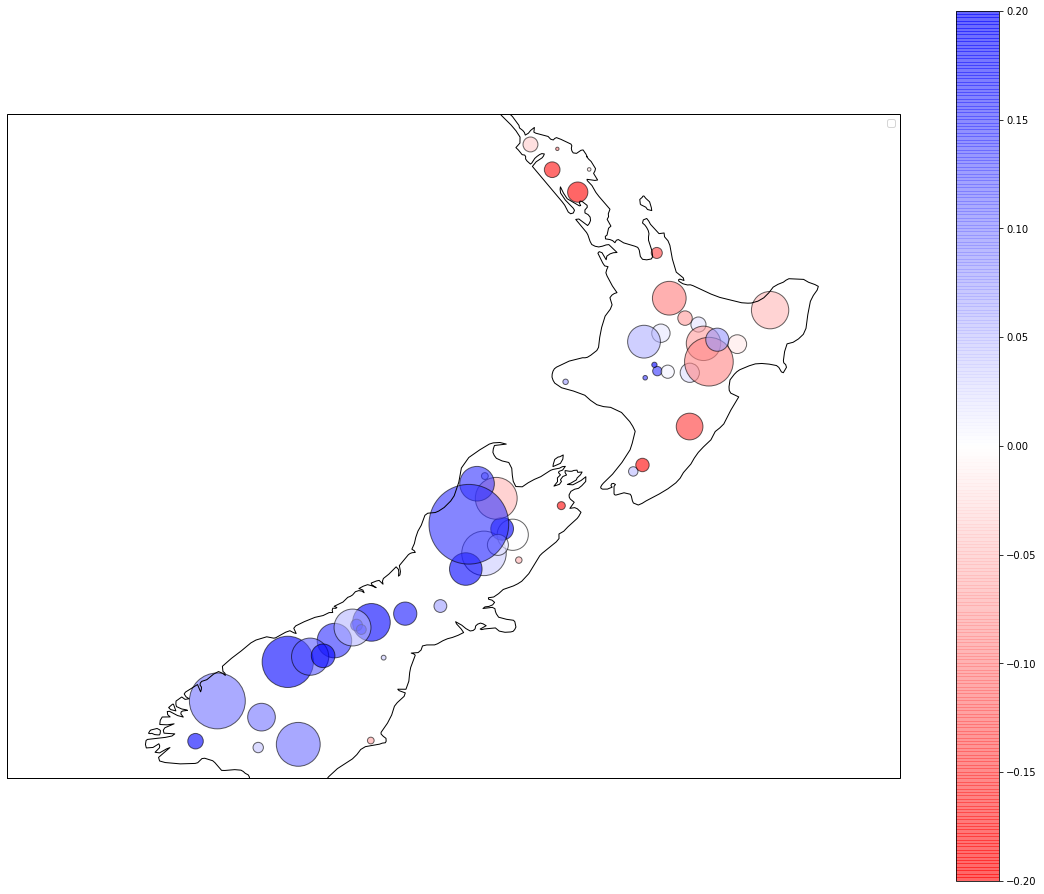

In [73]:
'''
Find anomalies rel to 1979-1999 and take average of records
'''

df = flow_df[flow_df.index.month.isin([season])]

fig, ax = plt.subplots(figsize=(20,16),subplot_kw={'projection': ccrs.PlateCarree()})

lons = []
lats = []
areas = []
taus = []
for site in df:
    lons.append(metadata_df.loc[int(site)]['centroid_lon'])
    lats.append(metadata_df.loc[int(site)]['centroid_lat'])
    areas.append(metadata_df.loc[int(site)]['area_km2'])
    
    vals = df[site].values
    years = df[site].index.year.values

    coef, p = kendalltau(years,vals,nan_policy='omit')
    taus.append(coef)
    
im = ax.scatter(lons,lats,s=areas,c=taus,cmap='bwr_r',vmin=-0.2,vmax=0.2,alpha=0.6,edgecolor='black')

ax.legend()
ax.coastlines(resolution='50m', color='black',linewidth=1)
ax.set_xlim([164,180])

fig.colorbar(im, ax=ax)



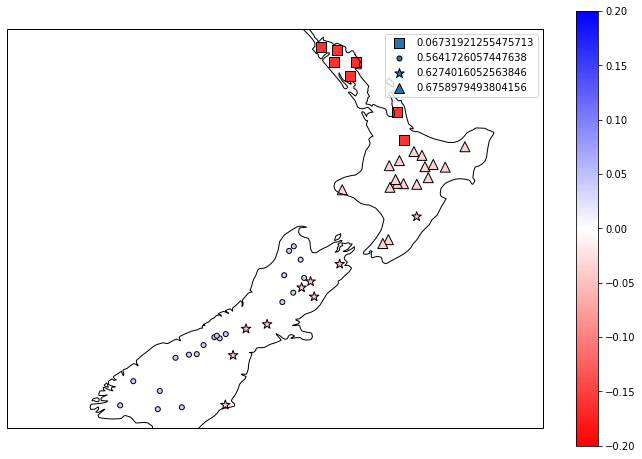

In [86]:
'''
Find anomalies rel to 1979-1999 and take average of records
'''

for season in [6]:#3,6,9,12]:
    df = flow_df[flow_df.index.month.isin([season])]

    fig, ax = plt.subplots(figsize=(12,8),subplot_kw={'projection': ccrs.PlateCarree()})

    for cluster in cluster_dict:

        #print(cluster_dict[cluster])
        cluster_df = df[[str(num) for num in cluster_dict[cluster]]]
        
        multiple_records_index = 0
        for i in range(len(cluster_df.index)):
            if np.count_nonzero(~np.isnan(cluster_df.iloc[i]))>1:
                multiple_records_index = i
                break

        cluster_df = cluster_df.iloc[multiple_records_index:]

        #cluster_df = (cluster_df - cluster_df.mean()) / cluster_df.std()
        cluster_df = (cluster_df - cluster_df['1979':'1999'].mean())/cluster_df['1979':'1999'].mean()

        lons = []
        lats = []
        taus = []

        #averaged_cluster = cluster_df.mean(axis=1,skipna=True)
        areas = []
        weight_scaled_cluster = cluster_df
        for site in cluster_df:
            weight_scaled_cluster[site] = weight_scaled_cluster[site]*metadata_df.loc[int(site)]['area_km2']
            areas.append(metadata_df.loc[int(site)]['area_km2'])
            
        averaged_cluster = weight_scaled_cluster.sum(axis=1,skipna=True) / np.sum(areas)
        
        #print(averaged_cluster)
        
        vals = averaged_cluster.values
        years = averaged_cluster.index.year.values

        coef, p = kendalltau(years,vals,nan_policy='omit')

        for site in cluster_dict[cluster]:
            lons.append(metadata_df.loc[site]['centroid_lon'])
            lats.append(metadata_df.loc[site]['centroid_lat'])
            taus.append(coef)

        im = ax.scatter(lons,lats,c=taus, cmap='bwr_r',marker=markers[cluster-1],vmin=-0.2,vmax=0.2,s=100,edgecolor='black',label=str(p))

    ax.legend()
    ax.coastlines(resolution='50m', color='black',linewidth=1)
    ax.set_xlim([164,180])

    fig.colorbar(im, ax=ax)



In [29]:
cluster_names = {}

cluster_names[1] = 'Northland'
cluster_names[2] = 'West SI'
cluster_names[3] = 'East SI'
cluster_names[4] = 'Central NI'


In [237]:
cluster_names = {}

cluster_names[1] = 'West SI + SW NI'
cluster_names[2] = 'East SI + NE NI'


                52916       57009       60114       64602       65104  \
date                                                                    
1932-06-01        NaN         NaN         NaN         NaN         NaN   
1933-06-01        NaN         NaN         NaN         NaN         NaN   
1934-06-01        NaN         NaN         NaN         NaN         NaN   
1935-06-01        NaN         NaN         NaN         NaN         NaN   
1936-06-01        NaN         NaN         NaN         NaN         NaN   
...               ...         ...         ...         ...         ...   
2015-06-01   7.711017   99.956435  130.710185  177.009271  232.653072   
2016-06-01   8.594665  306.517412  128.249766  -46.735253   42.245804   
2017-06-01 -11.627749 -419.131047   32.406419 -396.676247 -384.978558   
2018-06-01   5.950553  103.832649    0.349702  -22.336573   11.920406   
2019-06-01  -0.317078 -357.139486   51.953799 -244.926399 -119.450923   

                 71116       71120       71123    

Text(0.84, 0.9, 'tau = 0.042')

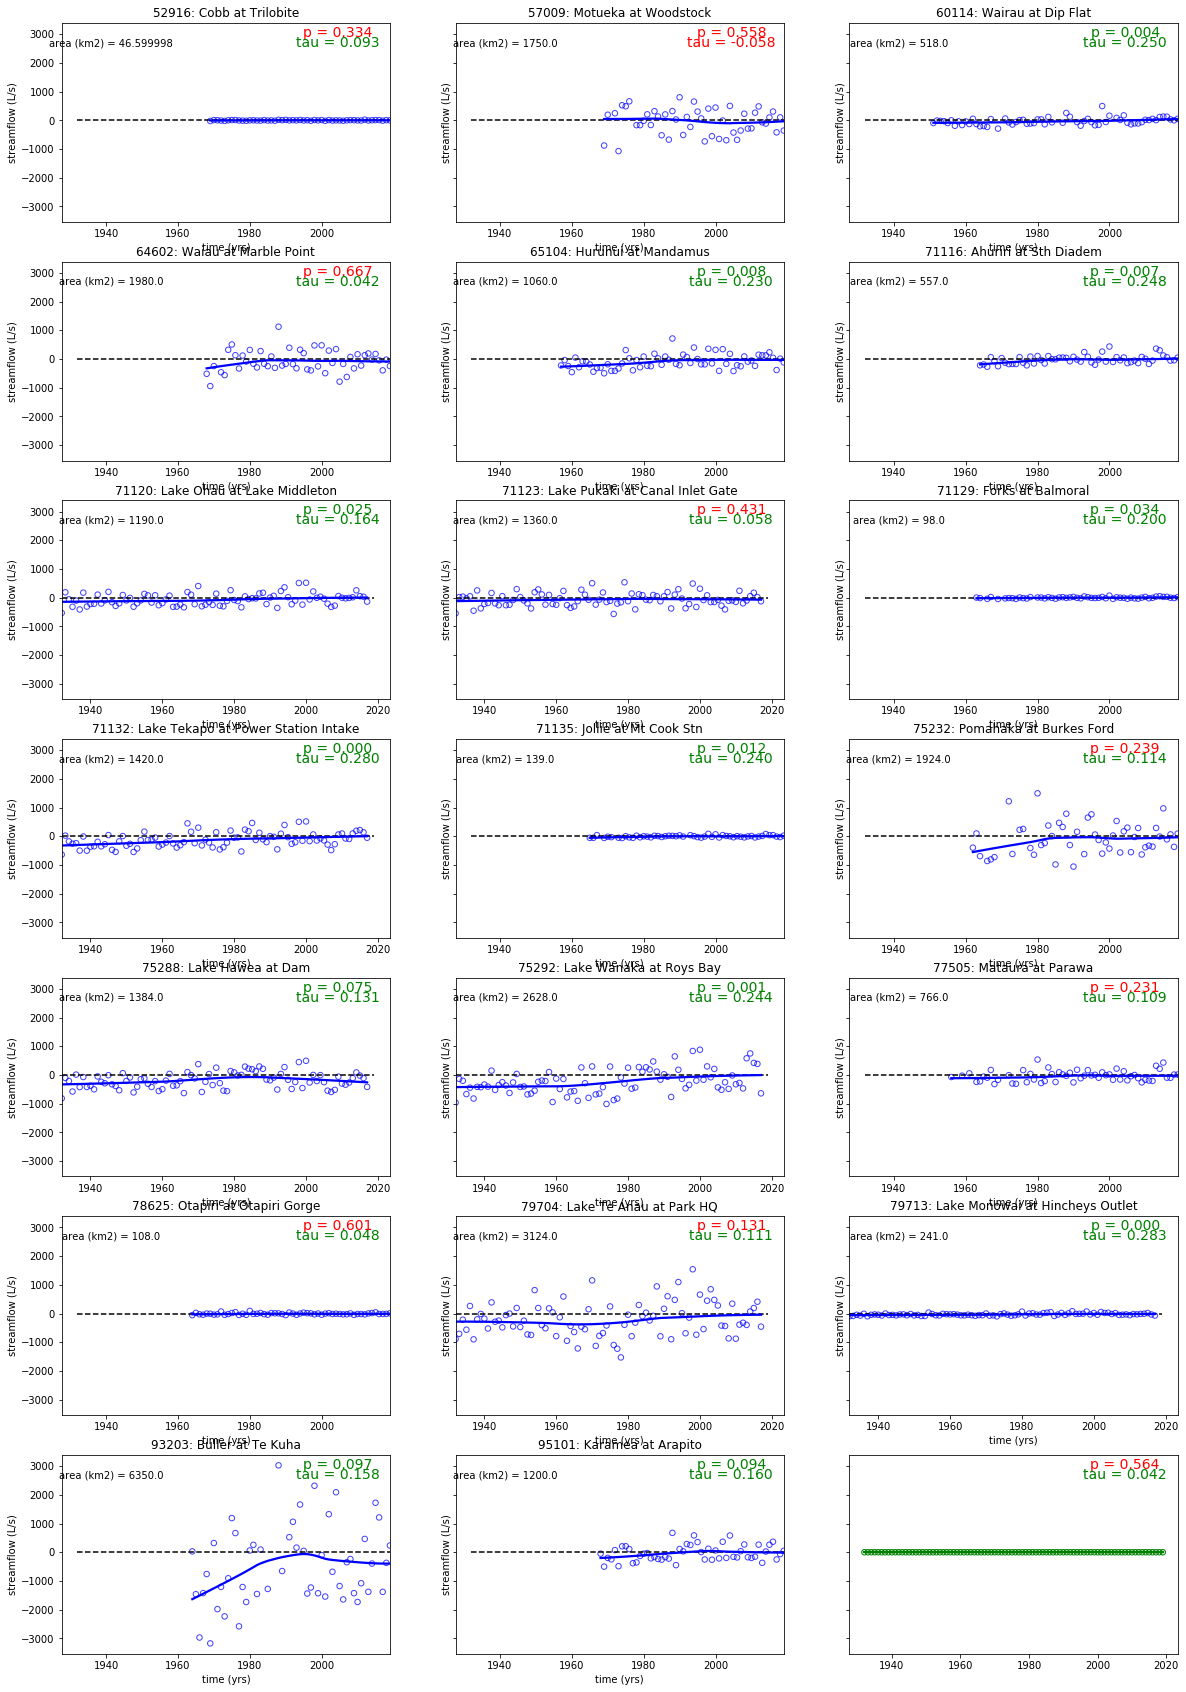

In [91]:
import seaborn as sns
from scipy.stats.mstats import theilslopes

df = flow_df[flow_df.index.month.isin([6])]

fig,axs = plt.subplots(len(cluster_dict[2])//3+1,3,figsize=(20,30),sharey=True)#,sharey=True)
axs = axs.flatten()

cluster_df = df[[str(num) for num in cluster_dict[2]]]

multiple_records_index = 0
for i in range(len(cluster_df.index)):
    if np.count_nonzero(~np.isnan(cluster_df.iloc[i]))>1:
        multiple_records_index = i
        break
        
cluster_df = cluster_df.iloc[multiple_records_index:]

#cluster_df = (cluster_df - cluster_df.mean()) / cluster_df.std()
cluster_df = (cluster_df - cluster_df['1979':'1999'].mean())/cluster_df['1979':'1999'].mean()
cluster_df = cluster_df*[float(metadata_df.loc[int(site)]['area_km2']) for site in cluster_df.columns]

print(cluster_df)
sites = []
ps = []

for i,site in enumerate(cluster_df):
    
    vals = cluster_df[site].values
    years = cluster_df[site].index.year.values
    
    coef, p = kendalltau(years, vals, nan_policy='omit')
    
    axs[i].scatter(years, vals, s=30, facecolors='none', edgecolors='blue',alpha=0.75)
    sns.regplot(years, vals, lowess=True, color = 'blue', label='lowess', scatter=False, ax=axs[i])

    axs[i].hlines(0,1932,2019,linestyles='dashed')
    axs[i].set_ylabel('streamflow (L/s)')
    axs[i].set_xlabel('time (yrs)')

    axs[i].text(0.84,.95, 'p = ' + "%.3f" % p, horizontalalignment="center", verticalalignment="center", fontsize=14,color="red" if p > 0.1 else 'green', transform=axs[i].transAxes)
    axs[i].text(0.84,.90, 'tau = ' + "%.3f" % coef, horizontalalignment="center", verticalalignment="center", fontsize=14, color = 'green' if coef > 0 else 'red', transform=axs[i].transAxes)

    axs[i].text(0.15,.9,'area (km2) = ' + str(metadata_df.loc[int(site)]['area_km2']), horizontalalignment="center", verticalalignment="center", transform=axs[i].transAxes)
 
    axs[i].set_title(str(site) + ': ' + metadata_df.loc[int(site)]['Name'])
    
    sites.append(site)
    ps.append(p)

#averaged_cluster = cluster_df.mean(axis=1,skipna=True)

averaged_cluster = cluster_df.sum(axis=1,skipna=True) / np.sum([float(metadata_df.loc[int(site)]['area_km2']) for site in cluster_df.columns])

#print(averaged_cluster)

vals = averaged_cluster.values
years = averaged_cluster.index.year.values

coef, p = kendalltau(years,vals,nan_policy='omit')
'''
for s in sites:
    print(s)
    
for v in ps:
    print(v)
    
print(" ")
print(p)
'''
axs[-1].scatter(years, vals, s=30, facecolors='none', edgecolors='green')
sns.regplot(years, vals, lowess=True, color = 'green', label='lowess', scatter=False, ax=axs[-1])

axs[-1].text(0.84,.95, 'p = ' + "%.3f" % p, horizontalalignment="center", verticalalignment="center", fontsize=14,color="red" if p > 0.1 else 'green', transform=axs[-1].transAxes)
axs[-1].text(0.84,.90, 'tau = ' + "%.3f" % coef, horizontalalignment="center", verticalalignment="center", fontsize=14, color = 'green' if coef > 0 else 'red', transform=axs[-1].transAxes)
#axs[-1].text(0.35,.75, "med slope = %.3f, (%.3f,%.3f)" % (medslope[0],medslope[2],medslope[3]), horizontalalignment="center", verticalalignment="center", fontsize=14, transform=axs[-1].transAxes)


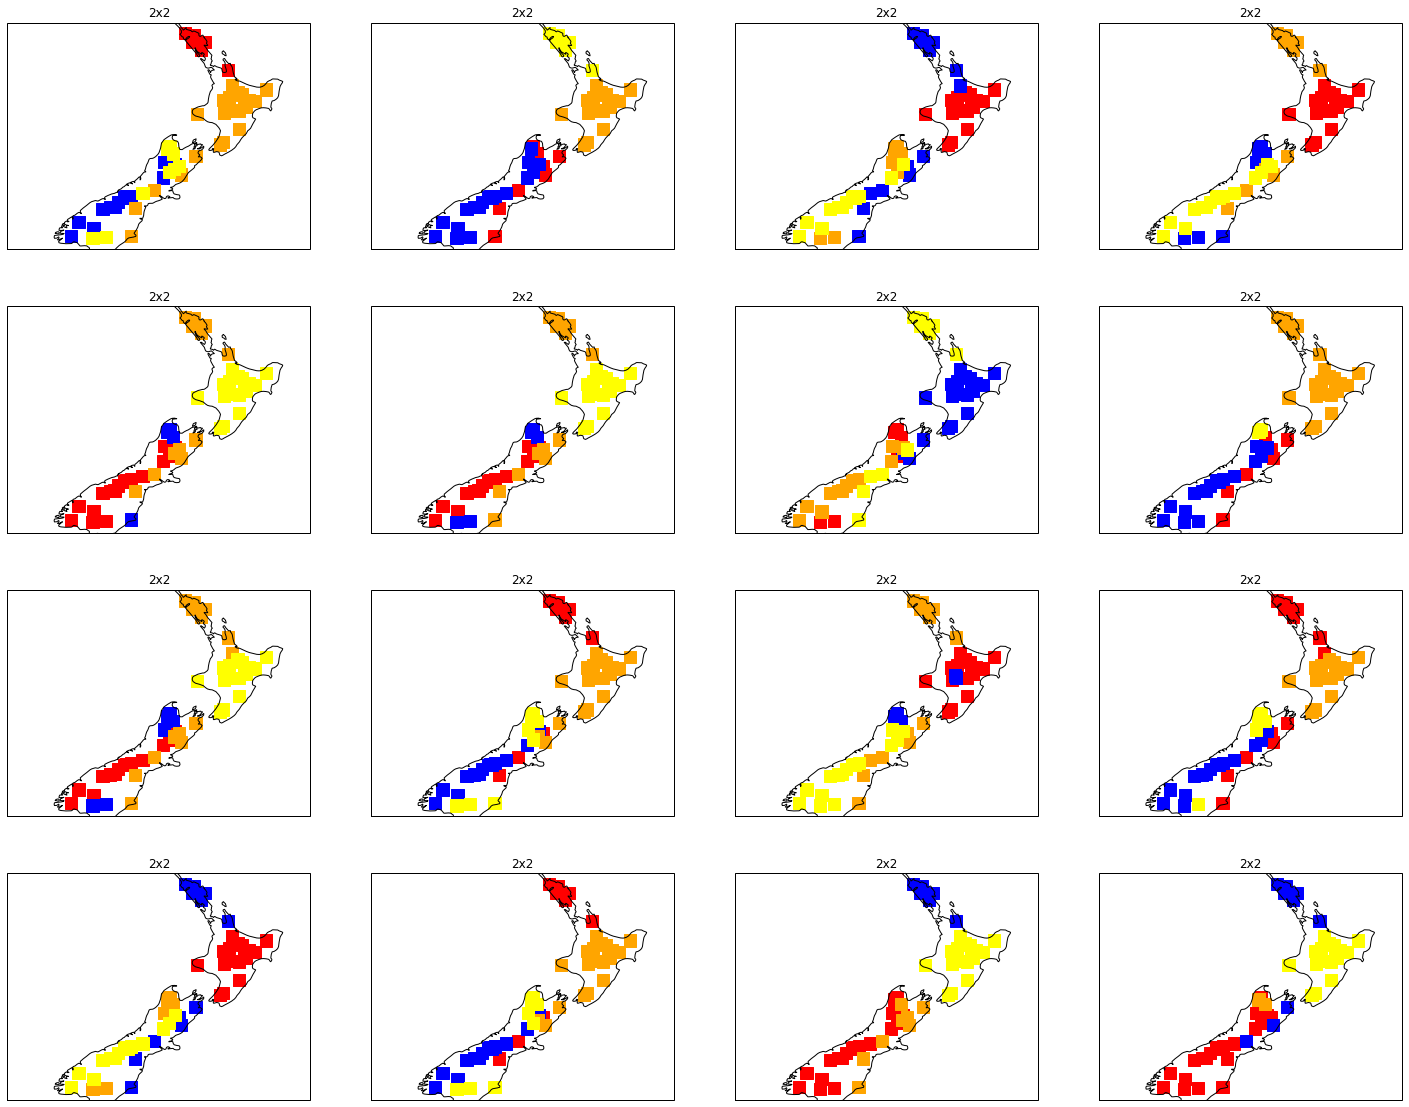

In [4]:
df = flow_df[flow_df.index.month.isin([6])]

df = df.fillna(df.mean())
normalized_df=((df-df.mean())/df.std()).T

mesh_sizes = [2]*16#3,4]
sites = normalized_df.index.values

#print(normalized_df)
X = normalized_df.values

fig, axs = plt.subplots(4,4,figsize=(25,20),squeeze=True,subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()

for i,size in enumerate(mesh_sizes):
    
    #print(i)
    
    som_x = som_y = size
    
    som = susi.SOMClustering(som_x,som_y,n_iter_unsupervised=50000,learning_rate_start=0.1,learning_rate_end=0.05,)
    som.fit(X)


    lons = []
    lats = []
    clusters = []

    for x in range(som_x):
        for y in range(som_y):
            cluster = (x,y)
            cluster_number = x*som_y+y+1

            series_indices = som.get_datapoints_from_node(cluster)

            for j in series_indices:
                site = int(sites[j])

                lons.append(metadata_df.loc[site]['centroid_lon'])
                lats.append(metadata_df.loc[site]['centroid_lat'])
                clusters.append(cluster_number)

    axs[i].scatter(lons,lats,c=[colors[val-1] for val in clusters],marker='s',s=150)

    axs[i].coastlines(resolution='50m', color='black', linewidth=1)
    axs[i].set_xlim([164,180])
    
    axs[i].set_title(str(size) + "x" + str(size))



([<matplotlib.axis.XTick at 0x2aab20c70518>,
 <a list of 4 Text xticklabel objects>)

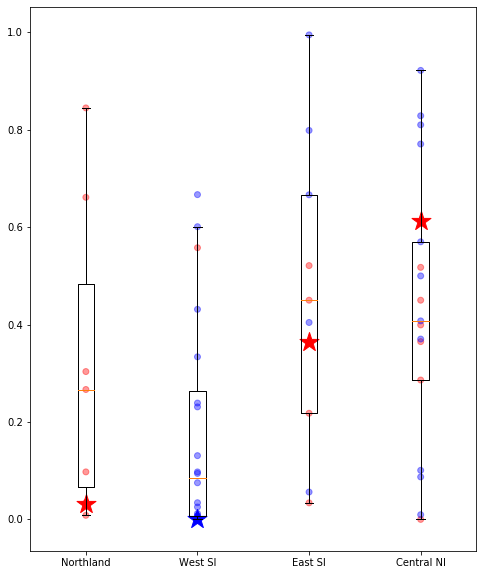

In [33]:
import seaborn as sns
from scipy.stats.mstats import theilslopes

fig,ax = plt.subplots(figsize=(8,10))

df = flow_df[flow_df.index.month.isin([6])]

cluster_p_dict = {}

for c in [1,2,3,4]:
    
    cluster_df = df[[str(num) for num in cluster_dict[c]]]

    multiple_records_index = 0
    for i in range(len(cluster_df.index)):
        if np.count_nonzero(~np.isnan(cluster_df.iloc[i]))>1:
            multiple_records_index = i
            break

    cluster_df = cluster_df.iloc[multiple_records_index:]

    cluster_df = (cluster_df - cluster_df['1979':'1999'].mean())/cluster_df['1979':'1999'].mean()

    sites = []
    taus = []
    ps = []

    for i,site in enumerate(cluster_df):
        vals = cluster_df[site].values
        years = cluster_df[site].index.year.values

        coef, p = kendalltau(years, vals, nan_policy='omit')
        '''
        axs[i].scatter(years, vals, s=30, facecolors='none', edgecolors='blue',alpha=0.75)
        sns.regplot(years, vals, lowess=True, color = 'blue', label='lowess', scatter=False, ax=axs[i])

        axs[i].hlines(0,1932,2019,linestyles='dashed')
        axs[i].set_ylabel('streamflow (L/s)')
        axs[i].set_xlabel('time (yrs)')

        axs[i].text(0.84,.95, 'p = ' + "%.3f" % p, horizontalalignment="center", verticalalignment="center", fontsize=14,color="red" if p > 0.1 else 'green', transform=axs[i].transAxes)
        axs[i].text(0.84,.90, 'tau = ' + "%.3f" % coef, horizontalalignment="center", verticalalignment="center", fontsize=14, color = 'green' if coef > 0 else 'red', transform=axs[i].transAxes)

        axs[i].text(0.15,.9,'area (km2) = ' + str(metadata_df.loc[int(site)]['area_km2']), horizontalalignment="center", verticalalignment="center", transform=axs[i].transAxes)

        axs[i].set_title(str(site) + ': ' + metadata_df.loc[int(site)]['Name'])
        '''
        sites.append(site)
        ps.append(p)
        taus.append(coef)

    averaged_cluster = cluster_df.mean(axis=1,skipna=True)

    vals = averaged_cluster.values
    years = averaged_cluster.index.year.values

    coef, p = kendalltau(years,vals,nan_policy='omit')
    
    plt.boxplot(ps,positions=[c],vert=True,sym='')
    #plt.boxplot(taus,positions=[c],vert=True,sym='')
    
    plt.scatter([c for i in range(len(ps))],ps,c=['red' if taus[i] < 0 else 'blue' for i in range(len(ps))],alpha=0.4)
    #plt.scatter([c for i in range(len(taus))],taus,c=['red' if taus[i] < 0 else 'blue' for i in range(len(taus))],alpha=0.4)
    
    plt.scatter(c,p,c='red' if coef < 0 else 'blue',marker='*',s=400)
    #plt.scatter(c,coef,c='red' if coef < 0 else 'blue',marker='*',s=400)

plt.xticks([1,2,3,4],[cluster_names[i] for i in [1,2,3,4]])
#axs[-1].scatter(years, vals, s=30, facecolors='none', edgecolors='green')
#sns.regplot(years, vals, lowess=True, color = 'green', label='lowess', scatter=False, ax=axs[-1])

#axs[-1].text(0.84,.95, 'p = ' + "%.3f" % p, horizontalalignment="center", verticalalignment="center", fontsize=14,color="red" if p > 0.1 else 'green', transform=axs[-1].transAxes)
#axs[-1].text(0.84,.90, 'tau = ' + "%.3f" % coef, horizontalalignment="center", verticalalignment="center", fontsize=14, color = 'green' if coef > 0 else 'red', transform=axs[-1].transAxes)
#axs[-1].text(0.35,.75, "med slope = %.3f, (%.3f,%.3f)" % (medslope[0],medslope[2],medslope[3]), horizontalalignment="center", verticalalignment="center", fontsize=14, transform=axs[-1].transAxes)


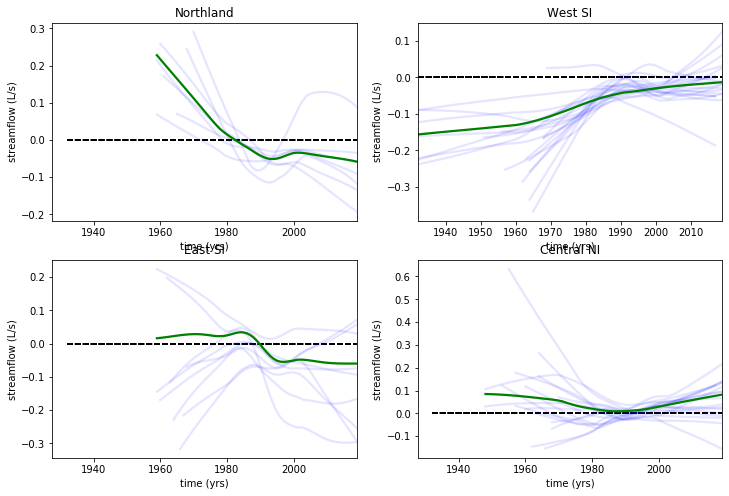

In [36]:
import seaborn as sns
from scipy.stats.mstats import theilslopes

fig,ax = plt.subplots(2,2,figsize=(12,8))
axs=ax.flatten()

df = flow_df[flow_df.index.month.isin([6])]

for c in [1,2,3,4]:
    
    cluster_df = df[[str(num) for num in cluster_dict[c]]]

    multiple_records_index = 0
    for i in range(len(cluster_df.index)):
        if np.count_nonzero(~np.isnan(cluster_df.iloc[i]))>1:
            multiple_records_index = i
            break

    cluster_df = cluster_df.iloc[multiple_records_index:]


    cluster_df = (cluster_df - cluster_df['1979':'1999'].mean())/cluster_df['1979':'1999'].mean()

    sites = []
    taus = []
    ps = []

    for i,site in enumerate(cluster_df):
        vals = cluster_df[site].values
        years = cluster_df[site].index.year.values

        coef, p = kendalltau(years, vals, nan_policy='omit')
        
        #axs[c-1].scatter(years, vals, s=30, facecolors='none', edgecolors='blue',alpha=0.75)
        sns.regplot(years, vals, lowess=True, color = 'blue', label='lowess', scatter=False, ax=axs[c-1],line_kws={'alpha':0.1})

        axs[c-1].hlines(0,1932,2019,linestyles='dashed')
        axs[c-1].set_ylabel('streamflow (L/s)')
        axs[c-1].set_xlabel('time (yrs)')

        #axs[c-1].text(0.84,.95, 'p = ' + "%.3f" % p, horizontalalignment="center", verticalalignment="center", fontsize=14,color="red" if p > 0.1 else 'green', transform=axs[c-1].transAxes)
        #axs[c-1].text(0.84,.90, 'tau = ' + "%.3f" % coef, horizontalalignment="center", verticalalignment="center", fontsize=14, color = 'green' if coef > 0 else 'red', transform=axs[c-1].transAxes)

        #axs[c-1].text(0.15,.9,'area (km2) = ' + str(metadata_df.loc[int(site)]['area_km2']), horizontalalignment="center", verticalalignment="center", transform=axs[c-1].transAxes)

        #axs[c-1].set_title(str(site) + ': ' + metadata_df.loc[int(site)]['Name'])
        
        sites.append(site)
        ps.append(p)
        taus.append(coef)

    averaged_cluster = cluster_df.mean(axis=1,skipna=True)

    vals = averaged_cluster.values
    years = averaged_cluster.index.year.values

    coef, p = kendalltau(years,vals,nan_policy='omit')

    #axs[c-1].scatter(years, vals, s=30, facecolors='none', edgecolors='green')
    sns.regplot(years, vals, lowess=True, color = 'green', label='lowess', scatter=False, ax=axs[c-1])
    
    axs[c-1].set_title(cluster_names[c])
    


61
61
88
88
61
61
72
72


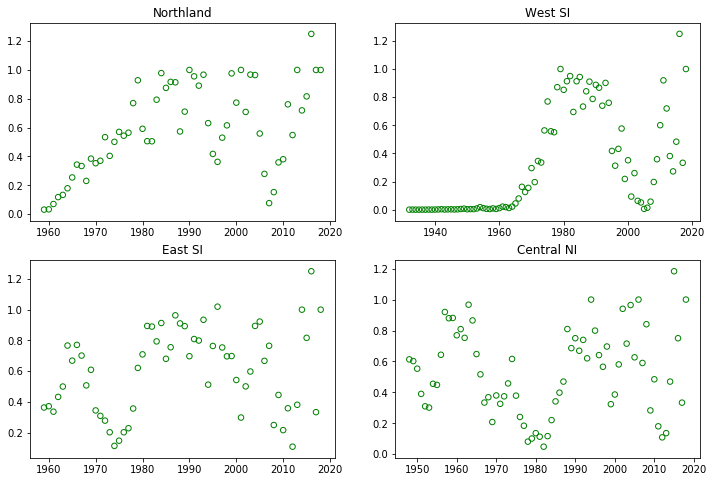

In [58]:
import seaborn as sns
from scipy.stats.mstats import theilslopes

fig,ax = plt.subplots(2,2,figsize=(12,8))
axs=ax.flatten()

df = flow_df[flow_df.index.month.isin([6])]

for c in [1,2,3,4]:
    
    cluster_df = df[[str(num) for num in cluster_dict[c]]]

    multiple_records_index = 0
    for i in range(len(cluster_df.index)):
        if np.count_nonzero(~np.isnan(cluster_df.iloc[i]))>1:
            multiple_records_index = i
            break

    cluster_df = cluster_df.iloc[multiple_records_index:]
    cluster_df = (cluster_df - cluster_df['1979':'1999'].mean())/cluster_df['1979':'1999'].mean()

    ps = []
    
    for start_year in cluster_df.index.year.tolist():
        subset = cluster_df[str(start_year):]
        averaged_cluster = subset.mean(axis=1,skipna=True)
                
        vals = averaged_cluster.values
        years = averaged_cluster.index.year.values

        coef, p = kendalltau(years,vals,nan_policy='omit')
        
        ps.append(p)


    axs[c-1].scatter(cluster_df.index.year.values, ps, s=30, facecolors='none', edgecolors='green')
    #sns.regplot(averaged_cluster.index.year.values, ps, lowess=True, color = 'green', label='lowess', scatter=False, ax=axs[c-1])
    
    axs[c-1].set_title(cluster_names[c])
    


In [45]:
cluster_df[str(cluster_df.index.year.tolist()[0]):]
    
    

,1043427,1043428,1043461,1043466,15408,15410,16501,21412,21801,23104,29224,29808,33117,33316,33347,36001,43472
date,,,,,,,,,,,,,,,,,
1949-03-01,NaN,NaN,NaN,NaN,-0.011342,NaN,NaN,-0.349180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-03-01,NaN,NaN,NaN,NaN,-0.261664,NaN,NaN,0.421620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1951-03-01,NaN,NaN,NaN,NaN,-0.247217,NaN,NaN,0.773342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1952-03-01,NaN,NaN,NaN,NaN,-0.169695,NaN,NaN,-0.408632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1953-03-01,NaN,NaN,NaN,NaN,0.145366,NaN,NaN,-0.419530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-03-01,-0.121896,-0.186933,0.007799,-0.154366,-0.401905,-0.226879,-0.030920,-0.041038,-0.399935,-0.225548,0.117288,0.128351,0.167572,0.046478,0.097728,0.627281,-0.173868
2016-03-01,-0.084315,-0.177095,-0.185019,-0.147482,-0.273633,0.113860,-0.159113,-0.254756,-0.532520,-0.443397,-0.091050,-0.125122,-0.146175,-0.041027,-0.034977,-0.038849,-0.013515
2017-03-01,1.018939,1.230777,0.744172,0.227561,1.083868,NaN,0.423128,0.907648,1.390273,1.094082,0.166866,0.331038,0.414397,1.362023,0.445967,1.031221,1.272751
